### Analitica de Datos — Universidad de San Andres
### Clase 01: Exploracion, Manipulacion y Visualizacion

**Otoño 2026 · Negocios Digitales**

---

### Agenda

| # | Seccion | Temas |
|---|---|---|
| 1 | Setup | Instalacion e imports |
| 2 | Carga y primer vistazo | `read_csv`, `head`, `tail`, `shape` |
| 3 | Tipos y estadísticas | `info`, `describe`, `value_counts` |
| 4 | Calidad del dato | Nulos, duplicados, limpieza |
| 5 | Manipulacion | Filtros, columnas nuevas, ordenamiento, groupby |
| 6 | Visualizacion | Countplot, histograma, boxplot, scatter, heatmap |

###

---

**Dataset:** Startups de IA con datos reales (Crunchbase / TechCrunch / PitchBook, 2024-2025).
Empresas como OpenAI, Anthropic, xAI, DeepSeek, Mistral, Cursor, Canva, Waymo, Figure AI y mas.

| Columna | Descripcion |
|---|---|
| `startup` | Nombre de la empresa |
| `pais` | Pais de origen |
| `anio_fundacion` | Año de fundacion |
| `sector` | Categoria (LLM, Robotica, Coding AI...) |
| `ultima_ronda` | Etapa de la ultima ronda (Seed, Serie A/B/C...) |
| `monto_ronda_usd_mm` | Monto levantado en la ultima ronda (USD millones) |
| `valuacion_usd_mm` | Valuacion al momento de esa ronda (USD millones) |
| `empleados` | Cantidad de empleados |
| `inversores_clave` | Principales inversores |

###

---

### Setup y Librerias

In [20]:
!pip install pandas matplotlib seaborn --quiet

In [21]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

---

---
### Carga y Primer Vistazo

In [4]:
df_startups = pd.read_csv('startups.csv', index_col=0)

In [5]:
# Primeras 5 filas
df_startups.head()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
0,Weights AI,USA,2023,Plataforma ML,Seed,25.0,NaN,30,Sequoia Scout
1,Replit,USA,2016,Coding AI,Serie B,97.0,1160.0,200,"Andreessen Horowitz, Sequoia, Google"
2,Etched,USA,2022,AI Hardware / Chips,Seed,120.0,NaN,50,"Primary Venture, Y Combinator"
3,Magic AI,USA,2023,Coding AI,Serie C,320.0,NaN,100,"CapitalG, Sequoia, Jane Street"
4,Wiz,Israel,2020,Cybersecurity AI,Serie E,1000.0,12000.0,1800,"Sequoia, Andreessen Horowitz, Index Ventures"


In [6]:
# Ultimas 5 filas
df_startups.tail()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
111,Skild AI,USA,2023,Robotica,Serie A,300.0,1500.0,80,"Lightspeed, Coatue, Bezos Expeditions"
112,Duolingo,USA,2011,Edtech AI,Publica,NaN,12000.0,1000,Publica (NASDAQ: DUOL)
113,Together AI,USA,2022,Infraestructura Cloud,Serie B,305.0,3300.0,200,"Salesforce Ventures, Kleiner Perkins"
114,Synthell,USA,2022,Edtech AI,Seed,5.0,NaN,20,Y Combinator
115,Isomorphic Labs,UK,2021,Biotech AI,Serie A,600.0,3000.0,200,"Alphabet, Foresite Capital"


In [7]:
# (filas, columnas)
print(f"El dataset contiene {df_startups.shape[0]} filas y {df_startups.shape[1]} columnas")

El dataset contiene 116 filas y 9 columnas


In [8]:
# Nombres de las columnas
df_startups.columns.tolist()

['startup',
 'pais',
 'anio_fundacion',
 'sector',
 'ultima_ronda',
 'monto_ronda_usd_mm',
 'valuacion_usd_mm',
 'empleados',
 'inversores_clave']

---
### Tipos de dato y estadísticas

In [9]:
# Tipo de dato de cada columna + cuantos valores no son nulos
df_startups.info()

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   startup             116 non-null    str    
 1   pais                116 non-null    str    
 2   anio_fundacion      116 non-null    int64  
 3   sector              116 non-null    str    
 4   ultima_ronda        116 non-null    str    
 5   monto_ronda_usd_mm  104 non-null    float64
 6   valuacion_usd_mm    85 non-null     float64
 7   empleados           116 non-null    int64  
 8   inversores_clave    116 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 15.6 KB


In [10]:
# Estadisticas descriptivas de columnas numericas
df_startups.describe().round(2)

,anio_fundacion,monto_ronda_usd_mm,valuacion_usd_mm,empleados
count,116.00,104.00,85.00,116.00
mean,2018.89,740.41,14743.85,654.21
std,3.92,1555.39,46246.84,1004.31
min,2008.00,3.00,200.00,15.00
25%,2016.00,100.00,1250.00,150.00
50%,2019.00,231.00,3000.00,250.00
75%,2022.00,648.75,10000.00,625.00
max,2024.00,10000.00,300000.00,6000.00


`monto_ronda_usd_mm`: media ~USD 740M vs mediana ~USD 231M. Pocas mega-rondas (OpenAI 6.600M, xAI 6.000M, Databricks 10.000M) jalan el promedio hacia arriba. La mediana es el numero honesto.

`valuacion_usd_mm`: media ~USD 14.700M vs mediana ~USD 3.000M — OpenAI (USD 300.000M) es un outlier enorme que distorsiona completamente el promedio.

`empleados`: media 654 vs mediana 250 — mismo patron. Databricks (6.000) y Waymo (4.000) jalan la media.

In [11]:
# Comparar media vs mediana para ver el sesgo
cols = ['monto_ronda_usd_mm', 'valuacion_usd_mm', 'empleados']

for col in cols:
    media   = df_startups[col].mean()
    mediana = df_startups[col].median()
    ratio   = media / mediana
    print(f"{col}")
    print(f"  Media:   {media:>10,.0f}")
    print(f"  Mediana: {mediana:>10,.0f}")
    print(f"  Ratio:   {ratio:>10.1f}x  <- cuanto mas alto, mas sesgado")
    print()

monto_ronda_usd_mm
  Media:          740
  Mediana:        231
  Ratio:          3.2x  <- cuanto mas alto, mas sesgado

valuacion_usd_mm
  Media:       14,744
  Mediana:      3,000
  Ratio:          4.9x  <- cuanto mas alto, mas sesgado

empleados
  Media:          654
  Mediana:        250
  Ratio:          2.6x  <- cuanto mas alto, mas sesgado



In [12]:
# Los 3 mayores de cada columna — los culpables del sesgo
for col in cols:
    print(f"Top 3 por {col}:")
    print(df_startups.nlargest(3, col)[['startup', col]].to_string(index=False))
    print()

Top 3 por monto_ronda_usd_mm:
   startup  monto_ronda_usd_mm
Databricks             10000.0
    OpenAI              6600.0
    OpenAI              6600.0

Top 3 por valuacion_usd_mm:
   startup  valuacion_usd_mm
    OpenAI          300000.0
    OpenAI          300000.0
Databricks           62000.0

Top 3 por empleados:
   startup  empleados
Databricks       6000
     Canva       4500
     Waymo       4000



In [13]:
# Cuantas veces aparece cada valor — ordenado de mayor a menor
df_startups['startup'].value_counts()

startup
Weights AI         2
Apptronik          2
Darktrace          2
DeepSeek           2
World Labs         2
                  ..
Cerebras           1
Skild AI           1
Together AI        1
Synthell           1
Isomorphic Labs    1
Name: count, Length: 101, dtype: int64

In [14]:
# Cuantos valores distintos hay — devuelve un numero
df_startups['startup'].nunique()

101

In [15]:
# Cuales son los valores distintos — devuelve la lista
df_startups['startup'].unique()

<ArrowStringArray>
[     'Weights AI',          'Replit',          'Etched',        'Magic AI',
             'Wiz',          'Qdrant',   'Perplexity AI',         'Tabnine',
       'Apptronik',       'Darktrace',
 ...
          'Alifyz',         'Vast AI',       'Runway ML',          'Mercor',
          'PathAI',        'Cerebras',        'Skild AI',     'Together AI',
        'Synthell', 'Isomorphic Labs']
Length: 101, dtype: str

---
### Calidad del dato 

In [16]:
# Cuantos nulos hay por columna
df_startups.isnull().sum()

startup                0
pais                   0
anio_fundacion         0
sector                 0
ultima_ronda           0
monto_ronda_usd_mm    12
valuacion_usd_mm      31
empleados              0
inversores_clave       0
dtype: int64

In [19]:
# Tabla de nulos: cantidad y porcentaje
nulos = df_startups.isnull().sum()
porcentaje = (nulos / len(df_startups) * 100).round(1)

tabla_nulos = pd.DataFrame({
    'nulos': nulos,
    '%': porcentaje
})

tabla_nulos[tabla_nulos['nulos'] > 0].sort_values('nulos', ascending=False)

,nulos,%
valuacion_usd_mm,31,26.7
monto_ronda_usd_mm,12,10.3


In [18]:
# Lo mismo pero en porcentaje
(df_startups.isnull().sum() / len(df_startups) * 100).round(1)

startup                0.0
pais                   0.0
anio_fundacion         0.0
sector                 0.0
ultima_ronda           0.0
monto_ronda_usd_mm    10.3
valuacion_usd_mm      26.7
empleados              0.0
inversores_clave       0.0
dtype: float64


`valuacion_usd_mm` (~27%): DeepSeek es autofinanciada, algunas startups no divulgan valuacion publica.
`monto_ronda_usd_mm` (~10%): Midjourney nunca levanto ronda externa, empresas publicas no reportan monto reciente.

Estos nulos son **datos faltantes reales**, no errores del dataset. Seaborn los ignora automaticamente en los graficos.

In [35]:
# Ver filas que tienen nulo en valuacion
df_startups[df_startups['valuacion_usd_mm'].isnull()][['startup', 'pais', 'sector', 'ultima_ronda','valuacion_usd_mm']].head()

,startup,pais,sector,ultima_ronda,valuacion_usd_mm
0,Weights AI,USA,Plataforma ML,Seed,NaN
2,Etched,USA,AI Hardware / Chips,Seed,NaN
3,Magic AI,USA,Coding AI,Serie C,NaN
5,Qdrant,Alemania,Plataforma ML,Serie B,NaN
7,Tabnine,Israel,Coding AI,Serie C,NaN


In [26]:
# Cuantas filas duplicadas hay
df_startups.duplicated().sum()

15

In [34]:
# Ver los duplicados (keep=False muestra TODAS las ocurrencias)
df_startups[df_startups.duplicated(keep=False)].sort_values('startup').head()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
36,1X Technologies,Noruega,2014,Robotica,Serie B,100.0,NaN,200,"OpenAI, EQT Ventures"
65,1X Technologies,Noruega,2014,Robotica,Serie B,100.0,NaN,200,"OpenAI, EQT Ventures"
8,Apptronik,USA,2016,Robotica,Serie A,350.0,NaN,250,"Google, Capital Factory"
48,Apptronik,USA,2016,Robotica,Serie A,350.0,NaN,250,"Google, Capital Factory"
83,Covariant,USA,2017,Robotica,Serie C,222.0,2000.0,200,"Index Ventures, Tiger Global"


In [36]:
# Eliminar duplicados — conservar la primera ocurrencia
df_clean = df_startups.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Antes : {len(df_startups)} filas")
print(f"Despues: {len(df_clean)} filas")

Antes : 116 filas
Despues: 101 filas


`keep='first'` conserva la primera ocurrencia de cada fila duplicada y elimina las siguientes.
`reset_index(drop=True)` reinicia el indice desde 0 para que quede limpio.

A partir de aca trabajamos siempre con `df_clean`.

---
### Manipulacion

In [37]:
# Seleccionar Columnas y Filas
df_clean['startup'].head(10)

0       Weights AI
1           Replit
2           Etched
3         Magic AI
4              Wiz
5           Qdrant
6    Perplexity AI
7          Tabnine
8        Apptronik
9        Darktrace
Name: startup, dtype: str

In [38]:
# Seleccionar multiples columnas
df_clean[['startup', 'sector', 'valuacion_usd_mm']].head(10)

,startup,sector,valuacion_usd_mm
0,Weights AI,Plataforma ML,NaN
1,Replit,Coding AI,1160.0
2,Etched,AI Hardware / Chips,NaN
3,Magic AI,Coding AI,NaN
4,Wiz,Cybersecurity AI,12000.0
5,Qdrant,Plataforma ML,NaN
6,Perplexity AI,Busqueda / Agentes,9000.0
7,Tabnine,Coding AI,NaN
8,Apptronik,Robotica,NaN
9,Darktrace,Cybersecurity AI,2500.0


---
### Visualizacion

> Antes de cada grafico: **que pregunta de negocio estoy respondiendo?**

| Pregunta | Grafico |
|---|---|
| Cuantos hay por categoria? | `countplot` |
| Como se distribuye una variable? | `histplot` |
| Como varia la distribucion entre grupos? | `boxplot` |
| Se relacionan dos variables numericas? | `scatterplot / lmplot` |
| Que variables se mueven juntas? | `heatmap` |
| Top N valores? | `barh` horizontal |

In [42]:
# Paleta automatica de colores por sector
sectores = df_clean['sector'].unique()
colores  = sns.color_palette('tab20', n_colors=len(sectores))
sector_palette = dict(zip(sectores, colores))

### Countplot — distribucion por categoria

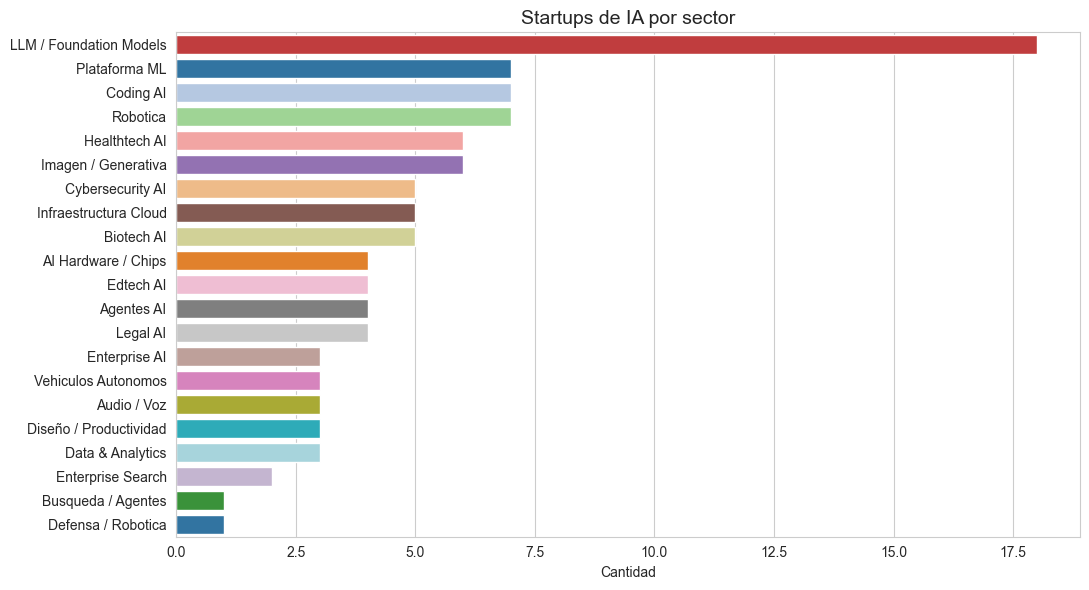

In [43]:
# Startups por sector — horizontal para labels largos
orden = df_clean['sector'].value_counts().index

plt.figure(figsize=(11, 6))
sns.countplot(data=df_clean, y='sector', order=orden,
              hue='sector', palette=sector_palette, legend=False)
plt.title('Startups de IA por sector', fontsize=14)
plt.xlabel('Cantidad')
plt.ylabel('')
plt.tight_layout()
plt.show()

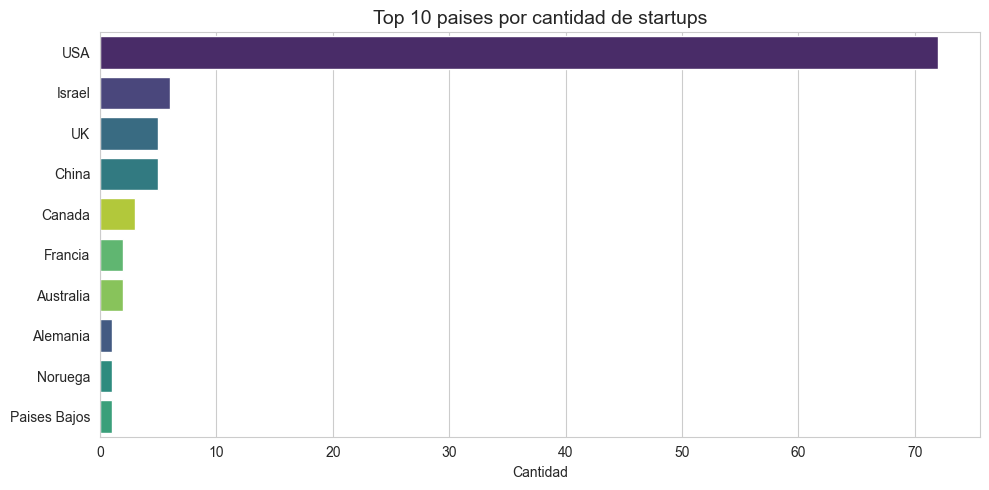

In [44]:
# Top 10 paises
orden_paises = df_clean['pais'].value_counts().head(10).index

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean[df_clean['pais'].isin(orden_paises)],
              y='pais', order=orden_paises,
              hue='pais', palette='viridis', legend=False)
plt.title('Top 10 paises por cantidad de startups', fontsize=14)
plt.xlabel('Cantidad')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Histograma — distribucion de variables numericas

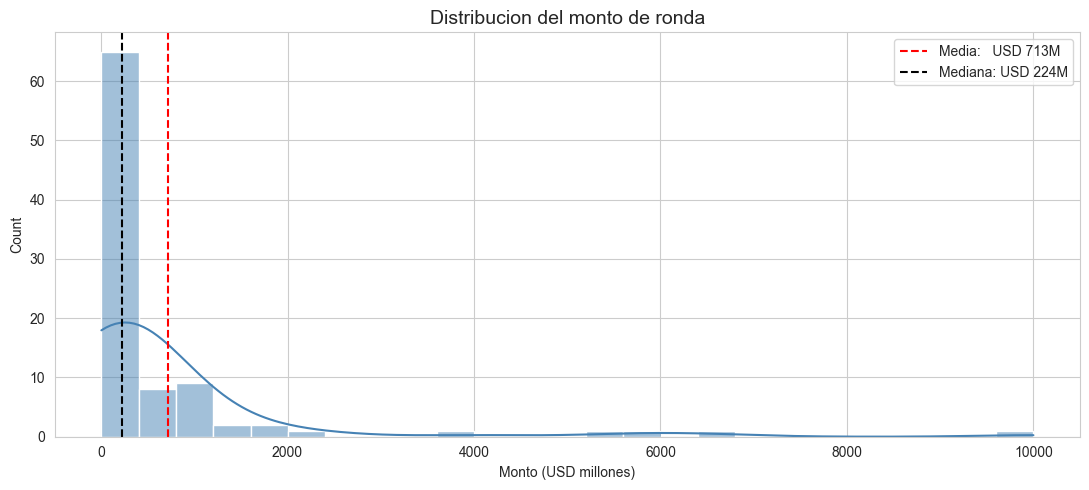

In [45]:
# Distribucion del monto de la ultima ronda
plt.figure(figsize=(11, 5))
sns.histplot(df_clean.dropna(subset=['monto_ronda_usd_mm']),
             x='monto_ronda_usd_mm', bins=25, kde=True, color='steelblue')

media   = df_clean['monto_ronda_usd_mm'].mean()
mediana = df_clean['monto_ronda_usd_mm'].median()

plt.axvline(media,   color='red',   linestyle='--', label=f'Media:   USD {media:,.0f}M')
plt.axvline(mediana, color='black', linestyle='--', label=f'Mediana: USD {mediana:,.0f}M')

plt.title('Distribucion del monto de ronda', fontsize=14)
plt.xlabel('Monto (USD millones)')
plt.legend()
plt.tight_layout()
plt.show()

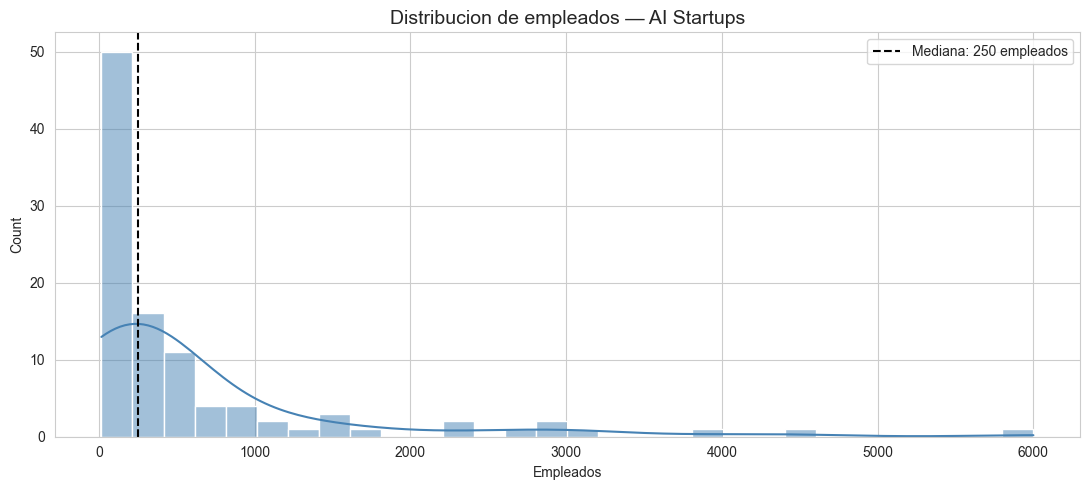

In [46]:
# Distribucion de empleados — comparando B2B vs autofinanciadas
plt.figure(figsize=(11, 5))
sns.histplot(df_clean, x='empleados', bins=30, kde=True, color='steelblue')
plt.axvline(df_clean['empleados'].median(), color='black', linestyle='--',
            label=f"Mediana: {df_clean['empleados'].median():.0f} empleados")
plt.title('Distribucion de empleados — AI Startups', fontsize=14)
plt.xlabel('Empleados')
plt.legend()
plt.tight_layout()
plt.show()